In [1]:
#==========================================================
# 1. 라이브러리 호출 
#==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve                   # 이상탐지 성능 평가를 위한 ROC_AUC 계산에 활용
from sklearn.metrics import confusion_matrix, classification_report    # 분류 모델의 평가 지표 계산을 위해 사용하는 함수 

np.random.seed(42)                                                     # 난수 고정을 위해 Numpy 시드 값을 설정
tf.random.set_seed(42)                                                 # 텐서플로우에서 동일한 시드 값을 설정

In [3]:
#==========================================================
# 2. 고장 원인별 가상 데이터 생성 
#==========================================================

n_per_class = 1000      # 각 클래스(원인결과) 당 샘플 수를 1000개로 설정
n_features = 5          # 센서 4개 + 공정 온도 특징 사용

# 클래스 0 : 정상(센서 값 0 근처, 온도 50도 근처)
normal = np.random.normal(loc=[0,0,0,0,50], scale=[1,1,1,1,3], size=(n_per_class, n_features))

# 클래스 1 : 센서불량(특정 센서1이 크게 튀는 데이터)
sensor_fault = np.random.normal(loc=[5,0,0,0,50], scale=[1.5,1,1,1,3], size=(n_per_class, n_features))

# 클래스 2 : 윤활 문제(진동 센서 3,4가 상승)
lubrication_fault = np.random.normal(loc=[0,0,4,4,50], scale=[1,1,1.5,1.5,3], size=(n_per_class, n_features))

# 클래스 3 : 냉각 문제(온도가 많이 상승)
cooling_fault = np.random.normal(loc=[0,0,0,0,70], scale=[1,1,1,1,4], size=(n_per_class, n_features))

# 네 클래스를 하나로 합침
X = np.vstack([normal, sensor_fault, lubrication_fault, cooling_fault])  # 4개원 원인 데이터를 위아래로 붙임

# 레이블 값에 대한 벡터를 만든다. 0,1,2,3 순서로 각 클래스에 해당하는 값을 부여
y = np.hstack([                    
    np.zeros(n_per_class),                # 클래스 0 : 정상         
    np.ones(n_per_class),                 # 클래스 1 : 센서 불량
    np.full(n_per_class,2),               # 클래스 2 : 윤활문제
    np.full(n_per_class,3)                # 클래스 3 : 냉각문제
]).astype(int)

In [4]:
#==========================================================
# 3. 학습/데이터 분리 및 스케일링 
#==========================================================

# 전체 데이터에서 70%를 학습용으로 사용하고, 30% 테스트용으로 나누고, 레이블 비율을 유지
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()                            # 평균 0, 분산1로 스케일을 맞춤
scaler.fit(X_train)                                  # 스케일러 기준을 계산

X_train_scaled = scaler.transform(X_train)          # 학습 입력 데이터 표준화
X_test_scaled = scaler.transform(X_test)            # 테스트 데이터도 표준화


In [5]:
#==========================================================
# 4. 다중 분류 DNN 모델 정의 
#==========================================================
num_classes = 4                     # 예측해야 할 클래스(원인)의 개수
input_dim = n_features              # 입력 차원은 5개 특징 수와 동일하게 설정

model = models.Sequential()                                 # 순차적으로 레이어를 쌓는 Sequential 모델 생성 
model.add(layers.Input(shape=(input_dim,)))                 # 첫 레이어로 입력 크기를 지정하는 Input 레이서 생성
model.add(layers.Dense(16, activation='relu'))              # 16개 뉴런의 레이어 추가, relu 활성화 함수 사용
model.add(layers.Dense(16, activation='relu'))              # 또 16개 뉴런의 레이어 추가, relu 활성화 함수 사용  <-- 모델 성능 강화 위함
model.add(layers.Dense(num_classes, activation='softmax'))     # 출력층은 클래스 개수만큼 뉴런을 두고 softmax로 각 원인에 대한 확률을 출력

model.summary()                      # 모델 구조를 출력해서 레이어 구성 확인

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │              96 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │              68 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 436 (1.70 KB)

 Trainable params: 436 (1.70 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
#==========================================================
# 5. 모델 컴파일 
#==========================================================
model.compile(
    optimizer='adam',                                        # 최적화 알고리즘은 adam 사용
    loss='sparse_categorical_crossentropy',                  # 정수 레이블용 다중 분류 손실 함수를 사용
    metrics=['accuracy']                                     # 평가지표 : 정확도
)

In [9]:
#==========================================================
# 6. 모델 학습 
#==========================================================

history = model.fit(  
    X_train_scaled,              # 표준화된 학습 입력 데이터 사용
    y_train,                            # 고장 원인 레이블을 타겟으로 사용
    epochs=40,                          # 40 반복 학습             
    batch_size=64,                      # 미니배치 크기 64
    validation_split=0.2,               # 학습데이터의 20% 검증
    verbose=1                           # 학습 진행상황을 로그로 출력
)

Epoch 1/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3991 - loss: 1.3065 - val_accuracy: 0.4518 - val_loss: 1.1761
Epoch 2/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5795 - loss: 1.0681 - val_accuracy: 0.6786 - val_loss: 0.9565
Epoch 3/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7705 - loss: 0.8390 - val_accuracy: 0.8464 - val_loss: 0.7203
Epoch 4/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9259 - loss: 0.5996 - val_accuracy: 0.9518 - val_loss: 0.4897
Epoch 5/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9710 - loss: 0.3849 - val_accuracy: 0.9625 - val_loss: 0.3101
Epoch 6/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9781 - loss: 0.2432 - val_accuracy: 0.9679 - val_loss: 0.2050
Epoch 7/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9790 - loss: 0.1689 - val_accuracy: 0.9732 - val_loss: 0.1499
Epoch 8/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9804 - loss: 0.1303 - val_accuracy: 0.9732 - val_loss:

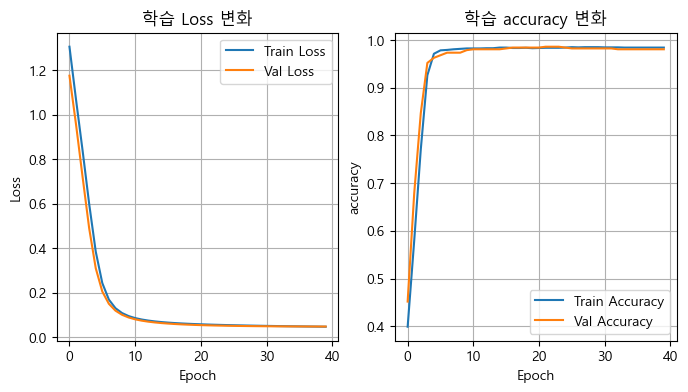

In [10]:
#==========================================================
# 7. 학습과정 시각화 
#==========================================================

# 그래프 한글 폰트 설정
from matplotlib import font_manager, rc
plt.rcParams['font.family'] = 'Malgun Gothic'          # 한글 폰트 지정
plt.rcParams['axes.unicode_minus'] = False             # 마이너스 부호 깨짐 방지

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)                                                  # 1행 2열의 서브플랏 생성하고, 첫번째 서브플랏을 사용한다.
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('학습 Loss 변화')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)                                                   # 1행 2열의 서브플랏 생성하고, 첫번째 서브플랏을 사용한다.
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('학습 accuracy 변화')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout                                                    # 서브플랏 간 간격을 자동으로 조정                             
plt.show()

In [26]:
#==========================================================
# 8. 테스트 데이터 평가 및 예측 
#==========================================================
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=1)    # 테스트 데이터에서 손실과 정확도 계산
print(f'테스트 정확도 : {test_acc:.3f}')                                   # 정확도 출력

y_pred_proba = model.predict(X_test_scaled)                               # 테스트 데이터의 샘플별 각 클래스 확률 계산
y_pred = np.argmax(y_pred_proba, axis=1)                                  # 가장 큰 확률을 가진 클래스를 최종 예측 레이블로 선택

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9742 - loss: 0.0679
테스트 정확도 : 0.974
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [27]:
#==========================================================
# 9. 학습 모델 결과 저장 
#==========================================================
import joblib
import os

# 학습된 모델을 HDF5(.h5) 파일 형식으로 저장한다.
save_path = "./data/model_detection.h5"
model.save(save_path)

print(f"\n 모델이 성공적으로 저장되었습니다: {save_path}")


 모델이 성공적으로 저장되었습니다: ./data/model_fault_detection.h5


In [32]:
#==========================================================
# 10. 모델 불러오기 
#==========================================================

loaded_model = tf.keras.models.load_model(save_path)
print('저장된 모델을 성공적으로 불러왔습니다.')


저장된 모델을 성공적으로 불러왔습니다.


In [33]:
#==========================================================
# 11. 예측 테스트 
#==========================================================

loaded_pred_proba = loaded_model.predict(X_test_scaled)
loaded_pred = np.argmax(loaded_pred_proba, axis=1)

print('저당된 모델 예측결과-상위 10개')
for i in range(10):
    print(f'샘플 {i+1} | 실제:{y_test[i]} --> 예측:{loaded_pred[i]}')
    


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
저당된 모델 예측결과-상위 10개
샘플 1 | 실제:3 --> 예측:3
샘플 2 | 실제:1 --> 예측:1
샘플 3 | 실제:2 --> 예측:2
샘플 4 | 실제:1 --> 예측:1
샘플 5 | 실제:3 --> 예측:3
샘플 6 | 실제:0 --> 예측:0
샘플 7 | 실제:3 --> 예측:3
샘플 8 | 실제:3 --> 예측:3
샘플 9 | 실제:0 --> 예측:0
샘플 10 | 실제:0 --> 예측:0


분류 리포트 : 
               precision    recall  f1-score   support

           0       0.95      0.95      0.95       300
           1       0.96      0.97      0.96       300
           2       0.99      0.98      0.98       300
           3       1.00      1.00      1.00       300

    accuracy                           0.97      1200
   macro avg       0.97      0.97      0.97      1200
weighted avg       0.97      0.97      0.97      1200



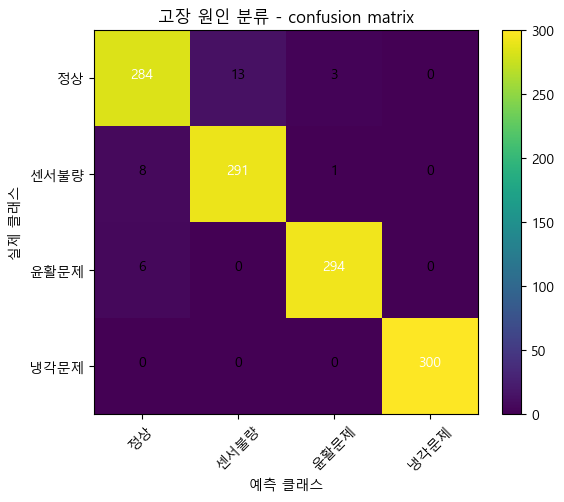

In [35]:
#==========================================================
# 12. Confusion Matrix   
#==========================================================
cm = confusion_matrix(y_test, y_pred)    
print('분류 리포트 : \n', classification_report(y_test, y_pred))    # 각 클래스별 정밀도, 재현율, f1 score 점수를 출력

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest')    
plt.title('고장 원인 분류 - confusion matrix')
plt.colorbar()    # 색상 막대
tick_marks = np.arange(num_classes)
class_names = ['정상','센서불량','윤활문제','냉각문제']
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j,i,cm[i,j],
                 horizontalalignment = 'center',
                 color='white' if cm[i,j] > thresh else 'black')

plt.ylabel('실제 클래스')
plt.xlabel('예측 클래스')
plt.tight_layout()
plt.show()


=== 테스트 데이터 예측 진단 결과 ===

[샘플 인덱스: 932 ]
센서/온도 값 = [ 1.18991972  0.93689919  0.53808479 -1.55869981 48.53558683]
실제 원인 = 정상
예측 원인 = 정상
예측 확률 벡터= [9.8312658e-01 1.6798785e-02 3.6896367e-05 3.7763562e-05]
가장 높은 예측 확률= 0.983

[샘플 인덱스: 1091 ]
센서/온도 값 = [-1.06741699  0.84938158 -0.37295851 -1.14490826 48.50930286]
실제 원인 = 정상
예측 원인 = 정상
예측 확률 벡터= [9.9996448e-01 2.2713421e-05 8.5027523e-06 4.3020377e-06]
가장 높은 예측 확률= 1.000

[샘플 인덱스: 16 ]
센서/온도 값 = [ 4.80952035  1.07455861 -0.73149742 -0.70549253 47.46758683]
실제 원인 = 센서불량
예측 원인 = 센서불량
예측 확률 벡터= [2.1428314e-04 9.9977714e-01 9.6024723e-07 7.6857114e-06]
가장 높은 예측 확률= 1.000

[샘플 인덱스: 832 ]
센서/온도 값 = [ 0.16138705 -0.25412582 -0.54816288 -0.66730961 45.18448867]
실제 원인 = 정상
예측 원인 = 정상
예측 확률 벡터= [9.9828511e-01 1.6531749e-03 5.2441923e-05 9.2521632e-06]
가장 높은 예측 확률= 0.998

[샘플 인덱스: 686 ]
센서/온도 값 = [ 2.81605244  0.05946593 -2.21612065 -2.15438371 47.48194413]
실제 원인 = 센서불량
예측 원인 = 센서불량
예측 확률 벡터= [5.9701115e-02 9.4027090e-01 9.8613418e-07 2.6998725e-05]


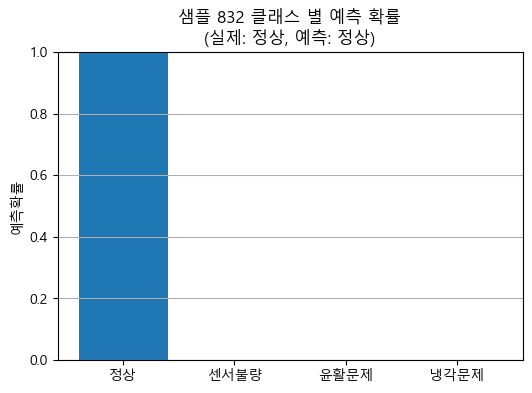

In [49]:
#==========================================================
# 13. 테스트 데이터에 대한 개별 예측 진단    
#==========================================================
#테스트 데이터 중 일부를 받아와서
# - 센서값 / 온도
# - 실제 고장 원인
# - 모델이 예측한 고장 원인
# - 예측 확률(신뢰도)
#출력해서 진단 결과 해석할 수 있도록 결과 제시

num_samples_to_show = 10   # 화면에 확인할 샘플 개수 10개 설정

# 테스트 데이터 인덱스 중에서 중복없이 무작위로 10개 추출
sample_indices = np.random.choice(len(X_test_scaled), size=num_samples_to_show, replace=False)

print('\n=== 테스트 데이터 예측 진단 결과 ===')
for idx in sample_indices:
    sensor_values = X_test[idx]          # 원본 스케일의 센서/온도 값을 가져옴
    true_label = y_test[idx]             # 실제 고장 원인 레이블(0~3)을 가져옴
    pred_label = y_pred[idx]             # 모델이 예측한 레이블(0~3)을 가져옴
    prob_vector = y_pred_proba[idx]      # 해당 샘플의 클래스별 예측 확률 벡터를 가져옴
    max_prob = np.max(prob_vector)       # 가장 큰 확률값을 계산

    print("\n[샘플 인덱스:", idx, "]")
    print('센서/온도 값 =', sensor_values)
    print('실제 원인 =', class_names[true_label])
    print('예측 원인 =', class_names[pred_label])
    print('예측 확률 벡터=', prob_vector)
    print('가장 높은 예측 확률=', f'{max_prob:.3f}')

sample_idx = sample_indices[3]
sample_prob = y_pred_proba[sample_idx]
sample_true = y_test[sample_idx]
sample_pred = y_pred[sample_idx]

plt.figure(figsize=(6,4))
plt.bar(range(num_classes), sample_prob)
plt.xticks(range(num_classes), class_names)
plt.ylim(0,1.0)
plt.ylabel('예측확률')
plt.title(
    f'샘플 {sample_idx} 클래스 별 예측 확률\n'
    f'(실제: {class_names[sample_true]}, 예측: {class_names[sample_pred]})'
)
plt.grid(True, axis='y')
plt.show()

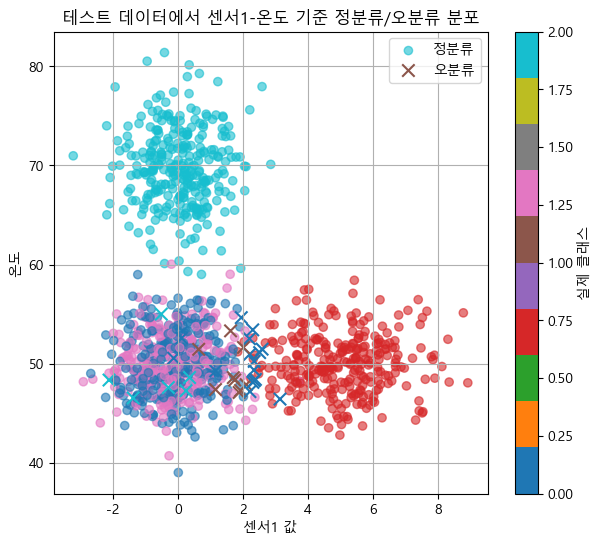

In [52]:
#==========================================================
# 14. 테스트 데이터에 대한 개별 예측 진단    
#==========================================================
# 5차원 데이터 중에서
#   - x축: 센서1 값 (첫 번째 센서)
#   - y축: 온도 (다섯 번째 특성)
# 로 두 축을 잡고
#   - 정분류 점: 동그라미(o)
#   - 오분류 점: X 표시
# 로 표시해 어떤 구간에서 오분류가 발생하는지 직관적으로 확인한다.

sensor_idx = 0                                             # x축에 사용할 센서 인덱스를 0번(첫 번째 센서)로 설정한다.
temp_idx = 4                                               # y축에 사용할 온도 인덱스를 4번(다섯 번째 특성)으로 설정한다.

correct_mask = (y_test == y_pred)                          # 실제 레이블과 예측 레이블이 같은지 여부를 나타내는 불리언 배열을 만든다.
incorrect_mask = ~correct_mask                             # 위 배열을 반전시켜 오분류 샘플을 나타내는 마스크를 만든다.

plt.figure(figsize=(7, 6))                                 # 산점도 그래프 크기를 설정한다.

# 정분류된 샘플들을 원형 마커로 표시한다.
plt.scatter(
    X_test[correct_mask, sensor_idx],                      # x좌표: 정분류 샘플의 센서1 값
    X_test[correct_mask, temp_idx],                        # y좌표: 정분류 샘플의 온도 값
    c=y_test[correct_mask],                                # 색상: 실제 클래스에 따라 색을 다르게 한다.
    cmap='tab10',                                          # 10가지 색상의 색상표를 사용한다.
    marker='o',                                            # 마커 모양을 동그라미로 설정한다.
    alpha=0.6,                                             # 투명도를 0.6으로 설정해 겹쳐도 잘 보이게 한다.
    label='정분류'
)

# 오분류된 샘플들을 X 마커로 표시한다.
plt.scatter(
    X_test[incorrect_mask, sensor_idx],                    # x좌표: 오분류 샘플의 센서1 값
    X_test[incorrect_mask, temp_idx],                      # y좌표: 오분류 샘플의 온도 값
    c=y_test[incorrect_mask],                              # 색상: 실제 클래스 기준으로 색을 입힌다.
    cmap='tab10',                                          # 동일한 색상표를 사용해 클래스 색을 맞춘다.
    marker='x',                                            # 마커 모양을 X로 설정해 오분류임을 강조한다.
    s=80,                                                  # 마커 크기를 80으로 설정해 눈에 잘 띄게 한다.
    linewidths=1.5,                                        # X 마커의 선 두께를 1.5로 설정한다.
    label='오분류'
)

plt.xlabel('센서1 값')                                     # x축 라벨을 센서1 값으로 설정한다.
plt.ylabel('온도')                                         # y축 라벨을 온도로 설정한다.
plt.title('테스트 데이터에서 센서1-온도 기준 정분류/오분류 분포')  # 그래프 제목을 설정한다.
plt.legend()                                               # 범례를 표시해 정분류/오분류를 구분한다.
plt.grid(True)                                             # 그리드를 표시해 좌표를 읽기 쉽게 한다.
plt.colorbar(label='실제 클래스')                          # 색상에 해당하는 실제 클래스를 나타내는 색상 막대를 추가한다.
plt.show()                                                 # 산점도 그래프를 화면에 표시한다.